In [113]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Data Loading 

In [114]:
df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")


# Inspection of Data

In [115]:
df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


Conclusion : Need of Encoding 

In [117]:
df.shape

(2000, 8)

In [118]:
df.isna().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [119]:
df=df.drop(columns="id")

In [120]:
df.duplicated().sum()

np.int64(183)

In [121]:
(df['answer'].value_counts()/df.shape[0])*100

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: count, dtype: float64

<Axes: xlabel='answer', ylabel='count'>

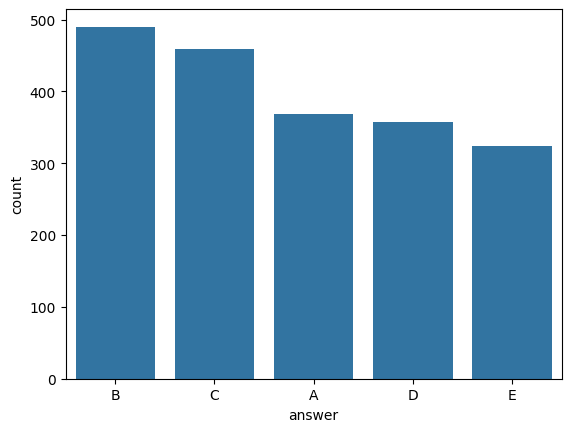

In [122]:
import seaborn as sns

sns.countplot(x=df['answer'], data=df, order=df['answer'].value_counts().index)

In [123]:
x=df['answer'].value_counts().max() +  df['answer'].value_counts().min()

print("Sum of Most frequent and least frequent options in answer column =",x)

Sum of Most frequent and least frequent options in answer column = 814


# Train Test Split

# Data cleaning 
Creating Vocab 
* removing punctuation
* split by space 

In [124]:
import string
has_punctuation = df["prompt"].apply(
    lambda text: any(c in string.punctuation for c in text)
)
print(has_punctuation.unique())

[ True]


In [125]:
import string
def clean_text(text):
    text=text.lower()
    text=text.strip()
    translator=str.maketrans('','',string.punctuation) #nothing,nothing,delete punctuation 
    text=text.translate(translator)
    return text
    

In [126]:
for col in ["prompt", "A", "B", "C", "D", "E"]:
    df[col] = df[col].apply(clean_text)
    test_df[col]=test_df[col].apply(clean_text)

In [127]:
#verifying 
has_punctuation = df["prompt"].apply(
    lambda text: any(c in string.punctuation for c in text)
)
print(has_punctuation.unique())

[False]


In [128]:
from sklearn.model_selection import train_test_split

X = df.drop(["answer"],axis=1)
y = df['answer']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [129]:
df.duplicated().sum()
df = df.drop_duplicates()

# Map@3 Metric 


In [130]:
def map3(y_true, top3_preds):
    score = 0

    for actual, pred in zip(y_true, top3_preds):
        if actual == pred[0]:
            score += 1.0

        elif actual == pred[1]:
            score += 0.5

        elif actual == pred[2]:
            score += 1/3

    return score / len(y_true)

# Base line model 

In [131]:
counts = df['answer'].value_counts()

top3 = counts.index[:3].tolist()

print(top3)

['B', 'C', 'D']


In [132]:
y_pred = [top3] * len(X_train)

In [133]:
print("Majority class baseline : ",round(map3(y_train,y_pred),3)) #train dataset and its a dummy classifier

Majority class baseline :  0.419


# Tfidf + cosine similarity 

In [134]:
train_text=pd.concat([
    X_train["prompt"],
    X_train["A"],
    X_train["B"],
    X_train["C"],
    X_train["D"],
    X_train["E"]
])

In [135]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer= TfidfVectorizer( ngram_range=(1,3), lowercase=False,
    max_features=80000,
    min_df=2,stop_words="english")
vectorizer.fit(train_text)


TfidfVectorizer(lowercase=False, max_features=80000, min_df=2,
                ngram_range=(1, 3), stop_words='english')

In [136]:
def transform_columns(df,vectorizer):
    return (
        vectorizer.transform(df["prompt"]),
        vectorizer.transform(df["A"]),
        vectorizer.transform(df["B"]),
        vectorizer.transform(df["C"]),
        vectorizer.transform(df["D"]),
        vectorizer.transform(df["E"])
    )

In [137]:
prompt_vec, A_vec, B_vec, C_vec, D_vec, E_vec = transform_columns(X_train, vectorizer)

prompt_val, A_val, B_val, C_val, D_val, E_val = transform_columns(X_val, vectorizer)


In [138]:
from sklearn.metrics.pairwise import cosine_similarity
print("shape of comparing prompt with A_vector",cosine_similarity(prompt_vec, A_vec).diagonal().shape)
scores = {
    'A': cosine_similarity(prompt_vec, A_vec).diagonal(),
    'B': cosine_similarity(prompt_vec, B_vec).diagonal(),
    'C': cosine_similarity(prompt_vec, C_vec).diagonal(),
    'D': cosine_similarity(prompt_vec, D_vec).diagonal(),
    'E': cosine_similarity(prompt_vec, E_vec).diagonal()
}
scores_val = {
    'A': cosine_similarity(prompt_val, A_val).diagonal(),
    'B': cosine_similarity(prompt_val, B_val).diagonal(),
    'C': cosine_similarity(prompt_val, C_val).diagonal(),
    'D': cosine_similarity(prompt_val, D_val).diagonal(),
    'E': cosine_similarity(prompt_val, E_val).diagonal()
}



shape of comparing prompt with A_vector (1600,)


In [139]:
def top3preds(scores_dict):
    preds = []

    for i in range(len(scores_dict["A"])):

        row_scores = {
            "A": scores_dict["A"][i],
            "B": scores_dict["B"][i],
            "C": scores_dict["C"][i],
            "D": scores_dict["D"][i],
            "E": scores_dict["E"][i]
        }

        top3 = []

        for k in range(3):

            best_opt = None
            best_score = -1

            for option, score in row_scores.items():

                if score > best_score:
                    best_score = score
                    best_opt = option

            top3.append(best_opt)
            row_scores.pop(best_opt)

        preds.append(top3)

    return preds

top3_list_val=top3preds(scores_val)
top3_list_train=top3preds(scores)

In [140]:
map3(y_train,top3_list_train)

0.3379166666666659

In [141]:
map3(y_val,top3_list_val)

0.3054166666666664

**Conclusion** Tfidf + cosine similarity gives 0.28 map@3 score on unknown data 

### LR model 
 

In [142]:
from sklearn.linear_model import LogisticRegression

Converting prompt to prompt+option format with label and when prompt and  true option is paired then gives label as 1 . thus converted multiclass labels to binary class labels 

In [143]:
def expand_to_binary(X, y):
    rows = []
    for (idx, row), label in zip(X.iterrows(), y):
        for opt in ['A', 'B', 'C', 'D', 'E']:
            rows.append({
                'text': row['prompt'] + ' ' + row[opt],
                'label': 1 if label == opt else 0
            })
    return pd.DataFrame(rows)


In [144]:

train_binary = expand_to_binary(X_train, y_train)
print("Train binary shape:", train_binary.shape)
print(train_binary['label'].value_counts())


Train binary shape: (8000, 2)
label
0    6400
1    1600
Name: count, dtype: int64


In [145]:

X_train_vec = vectorizer.fit_transform(train_binary['text'])  # fit ONLY on train

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, train_binary['label'])


LogisticRegression(max_iter=1000)

In [146]:

#  INFERENCE 
def predict_top3(row):

    options = ["A", "B", "C", "D", "E"]

    texts = []

    for option in options:
        texts.append(row["prompt"] + " " + row[option])

    probs = lr.predict_proba(vectorizer.transform(texts))[:, 1]

    scores = []

    for i in range(5):
        scores.append((options[i], probs[i]))

    scores.sort(key=lambda x: x[1], reverse=True)

    return [scores[0][0], scores[1][0], scores[2][0]]


In [147]:

top3_val = [predict_top3(row) for _, row in X_val.iterrows()]
print("Validation MAP@3:", round(map3(y_val, top3_val), 4))


Validation MAP@3: 0.9846


## Conclusion of lr model

The **0.9454** validation score reflects lexical memorization of training patterns, not true understanding. The **0.75** leaderboard score reflects real-world generalization. This gap motivates moving towards dl models for better generalization.

## Dl model 

In [148]:
from sklearn.model_selection import train_test_split

In [149]:
df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
# Step 1: drop exact duplicates
df_dedup = df.drop_duplicates(subset=["prompt","A","B","C","D","E","answer"], keep="first").reset_index(drop=True)

# Step 2: group remaining rows by prompt, so no prompt-group crosses train/val
df_dedup["dup_group"] = df_dedup.groupby("prompt").ngroup()

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df_dedup, groups=df_dedup["dup_group"]))

X_train = df_dedup.iloc[train_idx].drop(columns="answer")
X_val   = df_dedup.iloc[val_idx].drop(columns="answer")
y_train = df_dedup.iloc[train_idx]["answer"]
y_val   = df_dedup.iloc[val_idx]["answer"]

print(f"Train: {len(X_train)}, Val: {len(X_val)}")
total= X_train.shape[0] + X_val.shape[0]


Train: 1453, Val: 364


In [150]:
X_train.columns

Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'dup_group'], dtype='object')

In [151]:
import transformers
import torch
from transformers import AutoModel, BertTokenizerFast
import wandb

from kaggle_secrets import UserSecretsClient

print(wandb.__version__)


user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")
print(secret_value_0)
wandb.login(secret_value_0)
wandb.init( project="23f2005464-t22026", entity="23f2005464-iit-madras-",   name="bert-baseline")

device = torch.device("cuda")
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

0.25.1


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


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


batch_train_loss,▅▆▅▅▅▄█▂▃█▆▇▅▄▆▄▆▅▃▃▄▃▃▃▇▃▃▂▃▁▁▃▁▂▁▂▁▃▂▂
epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▁▂▂▃▄▄▅▅▆▆█▁▂▂▃▃▄▄▄▅▆▆▆▇▇██▁▂▃▃▃▄▄▅▆▆▇▇
batch_train_loss,0.13768
epoch,0
step,440


In [152]:
print("Model Max Length",tokenizer.model_max_length)
print("vocab size",tokenizer.vocab_size)

Model Max Length 512
vocab size 30522


In [153]:
prompt = "Which planet is known as the Red Planet?"
option = "Mars"

encoding = tokenizer(
    prompt,
    option,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

print(encoding.keys())


KeysView({'input_ids': tensor([[ 101, 2029, 4774, 2003, 2124, 2004, 1996, 2417, 4774, 1029,  102, 7733,
          102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        

In [154]:
import re

def clean_text(text):
    text = str(text)
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text
columns = ["prompt", "A", "B", "C", "D", "E"]

for col in columns:
    X_train[col] = X_train[col].apply(clean_text)
    X_val[col] = X_val[col].apply(clean_text)
    test_df[col]=test_df[col].apply(clean_text)
    

In [155]:
def pairs(df, y=None):
    rows = []

    for i, (_, row) in enumerate(df.iterrows()):
        prompt = row["prompt"]

        for option in ["A", "B", "C", "D", "E"]:

            pair = {
                "prompt": prompt,
                "option": row[option],
                "option_name": option
            }

            if y is not None:
                pair["label"] = int(y.iloc[i] == option)

            rows.append(pair)

    return pd.DataFrame(rows)

In [156]:
train_pairs=pairs(X_train,y_train)
val_pairs=pairs(X_val,y_val)
train_pairs.head()

,prompt,option,option_name,label
0,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,A,1
1,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,B,0
2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,C,0
3,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,D,0
4,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,E,0


Deciding length of token max_length allowed boundary

In [157]:

import numpy as np

lengths = []

for prompt, option in zip(train_pairs["prompt"], train_pairs["option"]):
    tokens = tokenizer.encode(prompt, option, add_special_tokens=True)
    lengths.append(len(tokens))


print("Maximum :", max(lengths))
print("Average :", np.mean(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("99th percentile:", np.percentile(lengths, 99))

Maximum : 200
Average : 60.59463179628355
95th percentile: 104.79999999999927
99th percentile: 131.0


options of max length 64, 128, 256, or 512  AND we are using 128 bcoz our 95 percentage of data is 105 or less.


In [158]:
x_train_encodings= tokenizer(
     train_pairs["prompt"].tolist(),
     train_pairs["option"].tolist(),
     padding="max_length",
     truncation=True,
     max_length=128,
     return_tensors="pt"
          )
x_val_encodings=tokenizer(
   val_pairs["prompt"].tolist(),
    val_pairs["option"].tolist(),
    padding="max_length",
    truncation=True,
     max_length=128,
      return_tensors="pt"
)
train_labels = torch.tensor(train_pairs["label"].tolist(), dtype=torch.long)
val_labels = torch.tensor(val_pairs["label"].tolist(), dtype=torch.long)

In [159]:
from torch.utils.data import TensorDataset
train_dataset = TensorDataset(
    x_train_encodings["input_ids"],
    x_train_encodings["attention_mask"],
    x_train_encodings["token_type_ids"],
    train_labels
)

val_dataset = TensorDataset(
    x_val_encodings["input_ids"],
    x_val_encodings["attention_mask"],
    x_val_encodings["token_type_ids"],
    val_labels
)

In [160]:
from torch.utils.data import DataLoader
train_loader=DataLoader(
    train_dataset,
      batch_size=16,
     shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

In [161]:
print(type(train_dataset))

<class 'torch.utils.data.dataset.TensorDataset'>


In [162]:
from transformers import BertForSequenceClassification
model=BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


cuda


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [163]:
batch = next(iter(train_loader))

print(type(batch))
print(len(batch))
print(type(batch[0]))

<class 'list'>
4
<class 'torch.Tensor'>


In [164]:
def train(model, train_loader, optimizer, device):

    model.train()

    running_loss = 0.0

    for step,(input_ids, attention_mask, token_type_ids, labels ) in enumerate(train_loader):

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        token_type_ids = token_type_ids.to(device)
        labels = labels.to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if step % 20 == 0: 
            wandb.log({"batch_train_loss": loss.item(), "epoch": epoch, "step": step})


    avg_loss = running_loss / len(train_loader)

    return avg_loss

In [167]:
import numpy as np
from sklearn.metrics import f1_score

def validate(model, val_loader, device, y_val):

    model.eval()

    running_loss = 0.0
    all_probs = []

    with torch.no_grad():

        for input_ids, attention_mask, token_type_ids, labels in val_loader:

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            token_type_ids = token_type_ids.to(device)
            labels = labels.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )

            running_loss += outputs.loss.item()

            probabilities = torch.softmax(outputs.logits, dim=1)

            # Probability of class 1 (correct option)
            correct_probability = probabilities[:, 1]

            all_probs.extend(correct_probability.cpu().numpy())


    avg_val_loss = running_loss / len(val_loader)

    option_names = ["A", "B", "C", "D", "E"]

    top3_answers = []
    top1_answers = []

    # Each question has 5 options
    for i in range(0, len(all_probs), 5):

        probs = all_probs[i:i+5]

        # Top 3 options for MAP@3
        indices = np.argsort(probs)[::-1][:3]

        top3_answers.append(
            [option_names[j] for j in indices]
        )

        # Top 1 option
        top1_answers.append(
            option_names[np.argmax(probs)]
        )


    # MAP@3 leaderboard metric
    val_map3 = map3(y_val, top3_answers)


    # Question-level accuracy
    question_accuracy = np.mean(
        [pred == true for pred, true in zip(top1_answers, y_val)]
    )


    # F1 score
    option_to_id = {
        "A": 0,
        "B": 1,
        "C": 2,
        "D": 3,
        "E": 4
    }

    pred_labels = [
        option_to_id[pred] for pred in top1_answers
    ]

    true_labels = [
        option_to_id[true] for true in y_val
    ]

    f1 = f1_score(
        true_labels,
        pred_labels,
        average="macro"
    )


    return avg_val_loss, val_map3, question_accuracy, f1

In [169]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5
)

epochs = 3

for epoch in range(epochs):
    train_loss=train(model,train_loader,optimizer,device)
    val_loss, val_map3, accuracy, f1 = validate(
        model,
        val_loader,
        device,
        y_val
    )
    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"MAP@3: {val_map3:.4f}"
    )

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_map3": val_map3,
        "question_accuracy": accuracy,
        "val/f1_score": f1
})



Epoch 1 | Train Loss: 0.2085 | Val Loss: 0.1559 | MAP@3: 0.9890
Epoch 2 | Train Loss: 0.1213 | Val Loss: 0.0837 | MAP@3: 0.9959
Epoch 3 | Train Loss: 0.0825 | Val Loss: 0.0638 | MAP@3: 0.9973


Auto model used


In [ ]:
import pandas as pd
from datasets import Dataset
import string

# Load data
df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

# Text cleaning
def clean_text(text):
    text = text.lower()
    text = text.strip()
    translator = str.maketrans('', '', string.punctuation)
    text = text.translate(translator)
    return text

# Clean all text columns
for col in ["prompt", "A", "B", "C", "D", "E"]:
    df[col] = df[col].apply(clean_text)
    test_df[col] = test_df[col].apply(clean_text)

# Convert Pandas DataFrame to Hugging Face Dataset
dataset = Dataset.from_pandas(df)
test_dataset = Dataset.from_pandas(test_df)
dataset = dataset.remove_columns("id")
test_dataset = test_dataset.remove_columns("id")

# Train-validation split
dataset = dataset.train_test_split(
    test_size=0.2,
    seed=42
)

train_dataset = dataset["train"]
val_dataset = dataset["test"]


print(train_dataset)
print(val_dataset)
print(test_dataset)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

option_cols = ["A", "B", "C", "D", "E"]

def custom_tokenize_mcq(examples):

    prompts = []
    options = []

    for i in range(len(examples["prompt"])):

        question = examples["prompt"][i]

        for option in option_cols:
            prompts.append(question)
            options.append(examples[option][i])

    tokenized = tokenizer(
        prompts,
        options,
        padding=True,
        truncation=True,
        max_length=128
    )

    output = {}

    for key in tokenized:

        grouped = []

        for i in range(0, len(tokenized[key]), 5):
            grouped.append(tokenized[key][i:i+5])

        output[key] = grouped

    # Convert answer labels if present
    if "answer" in examples:
        label_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
        output["labels"] = [label_map[a] for a in examples["answer"]]

    return output

In [ ]:
train_tokenized = train_dataset.map(
    custom_tokenize_mcq,
    batched=True,
    remove_columns=train_dataset.column_names
)

val_tokenized = val_dataset.map(
    custom_tokenize_mcq,
    batched=True,
    remove_columns=val_dataset.column_names
)

test_tokenized = test_dataset.map(
    custom_tokenize_mcq,
    batched=True,
    remove_columns=test_dataset.column_names
)

In [ ]:
import torch
from transformers import AutoModelForMultipleChoice

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model with 6 classification labels


model = AutoModelForMultipleChoice.from_pretrained(
    "distilbert-base-uncased"
)

# Move to the chosen device
model.to(device)
print(f"Model successfully loaded to {device}")

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./my_results",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
        run_name="distilbert-mcq",
       report_to="wandb",
     eval_strategy="epoch",
    save_strategy="epoch",
)

In [ ]:
!pip install -q evaluate

In [ ]:
import numpy as np
import evaluate

# Load the accuracy metric
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Argmax on the last axis gets the index of the highest logit
    predictions = np.argmax(logits, axis=-1)

    # Compute and return the score
    return metric.compute(predictions=predictions, references=labels)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
    
)

In [ ]:
# Execute the training loop!
trainer.train()

In [ ]:
trainer.evaluate()

In [ ]:
import numpy as np
import pandas as pd

# Predict on test set
test_predictions = trainer.predict(test_tokenized)

# Logits: shape (num_examples, 5)
logits = test_predictions.predictions

# Get indices of the top 3 scores for each example
top3_indices = np.argsort(logits, axis=1)[:, -3:][:, ::-1]

label_map = {
    0: "A",
    1: "B",
    2: "C",
    3: "D",
    4: "E"
}

# Convert indices to "A B C" format
top3_answers = [
    " ".join(label_map[idx] for idx in row)
    for row in top3_indices
]

submission = pd.DataFrame({
    "id": test_df["id"],
    "prediction": top3_answers
})

submission.to_csv("submission.csv", index=False)